In [1]:
import h5py

In [2]:
f = h5py.File('/scratch/saporito/Frag3D/sim_vel1.0e+03_sf4.0e-01_T1.0e-05_k4.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00/data.h5', 'r')

In [3]:
list(f.keys())

['step_0',
 'step_1008',
 'step_1017',
 'step_1026',
 'step_1035',
 'step_1044',
 'step_1053',
 'step_1062',
 'step_1071',
 'step_108',
 'step_1080',
 'step_1089',
 'step_1098',
 'step_1107',
 'step_1116',
 'step_1125',
 'step_1134',
 'step_1143',
 'step_1152',
 'step_1161',
 'step_117',
 'step_1170',
 'step_1179',
 'step_1188',
 'step_1197',
 'step_1206',
 'step_1215',
 'step_1224',
 'step_1233',
 'step_1242',
 'step_1251',
 'step_126',
 'step_1260',
 'step_1269',
 'step_1278',
 'step_1287',
 'step_1296',
 'step_1305',
 'step_1314',
 'step_1323',
 'step_1332',
 'step_1341',
 'step_135',
 'step_1350',
 'step_1359',
 'step_1368',
 'step_1377',
 'step_1386',
 'step_1395',
 'step_1404',
 'step_1413',
 'step_1422',
 'step_1431',
 'step_144',
 'step_1440',
 'step_1449',
 'step_1458',
 'step_1467',
 'step_1476',
 'step_1485',
 'step_1494',
 'step_1503',
 'step_1512',
 'step_1521',
 'step_153',
 'step_1530',
 'step_1539',
 'step_1548',
 'step_1557',
 'step_1566',
 'step_1575',
 'step_1584',
 

In [4]:
final_step = f['step_9774']

In [5]:
print(final_step.attrs.keys())

<KeysViewHDF5 ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']>


In [6]:
final_masses = final_step['fragment_mass'][:]
final_velocities = final_step['fragment_velocity'][:]
final_com = final_step['fragment_COM'][:]
print(final_masses)
print(final_velocities)
print(final_com)

[1.35673146e-07 1.35673146e-07 1.35673146e-07 ... 6.23352537e-08
 6.23352537e-08 6.23352537e-08]
[[  6.79272376  -1.12955999 436.95610006]
 [ -4.97474552  -7.22757087 454.15267957]
 [ -5.44866734 -10.72520022 335.06375319]
 ...
 [-15.14852086  -3.18550508  68.2725975 ]
 [-26.07739175  29.33221295  43.93315764]
 [  1.68791079   3.61203917  78.143295  ]]
[[-1.93103410e-03 -6.54287038e-04  9.51782243e-05]
 [-1.93103410e-03 -6.54287038e-04 -1.04821776e-04]
 [ 7.91877962e-04 -2.21056828e-03 -1.29054052e-20]
 ...
 [ 3.71155560e-03 -2.96411606e-04 -3.00000000e-04]
 [-2.66287338e-04 -3.76580252e-03 -2.48730842e-04]
 [-3.71155560e-03  2.96411606e-04 -3.00000000e-04]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# gotta extract the steps' number from f.keys()
sorted_keys = sorted(f.keys(), key=lambda x: int(x.split('_')[-1]))

In [9]:
# Savding variation of ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']
# wrt their value in step_0 at each step
econ = []
edis = []
ekin = []
epot = []
erev = []
nb_fragments = []
total_energy = []
for step in sorted_keys:
    step_data = f[step]
    econ.append(step_data.attrs['econ'])
    edis.append(step_data.attrs['edis'])
    ekin.append(step_data.attrs['ekin'])
    epot.append(step_data.attrs['epot'])
    erev.append(step_data.attrs['erev'])
    nb_fragments.append(step_data.attrs['nb_fragments'])
    total_energy.append(step_data.attrs['total_energy'])
steps = np.array(sorted_keys)
econ = np.array(econ)
edis = np.array(edis)
ekin = np.array(ekin)
epot = np.array(epot)
erev = np.array(erev)
nb_fragments = np.array(nb_fragments)
total_energy = np.array(total_energy)

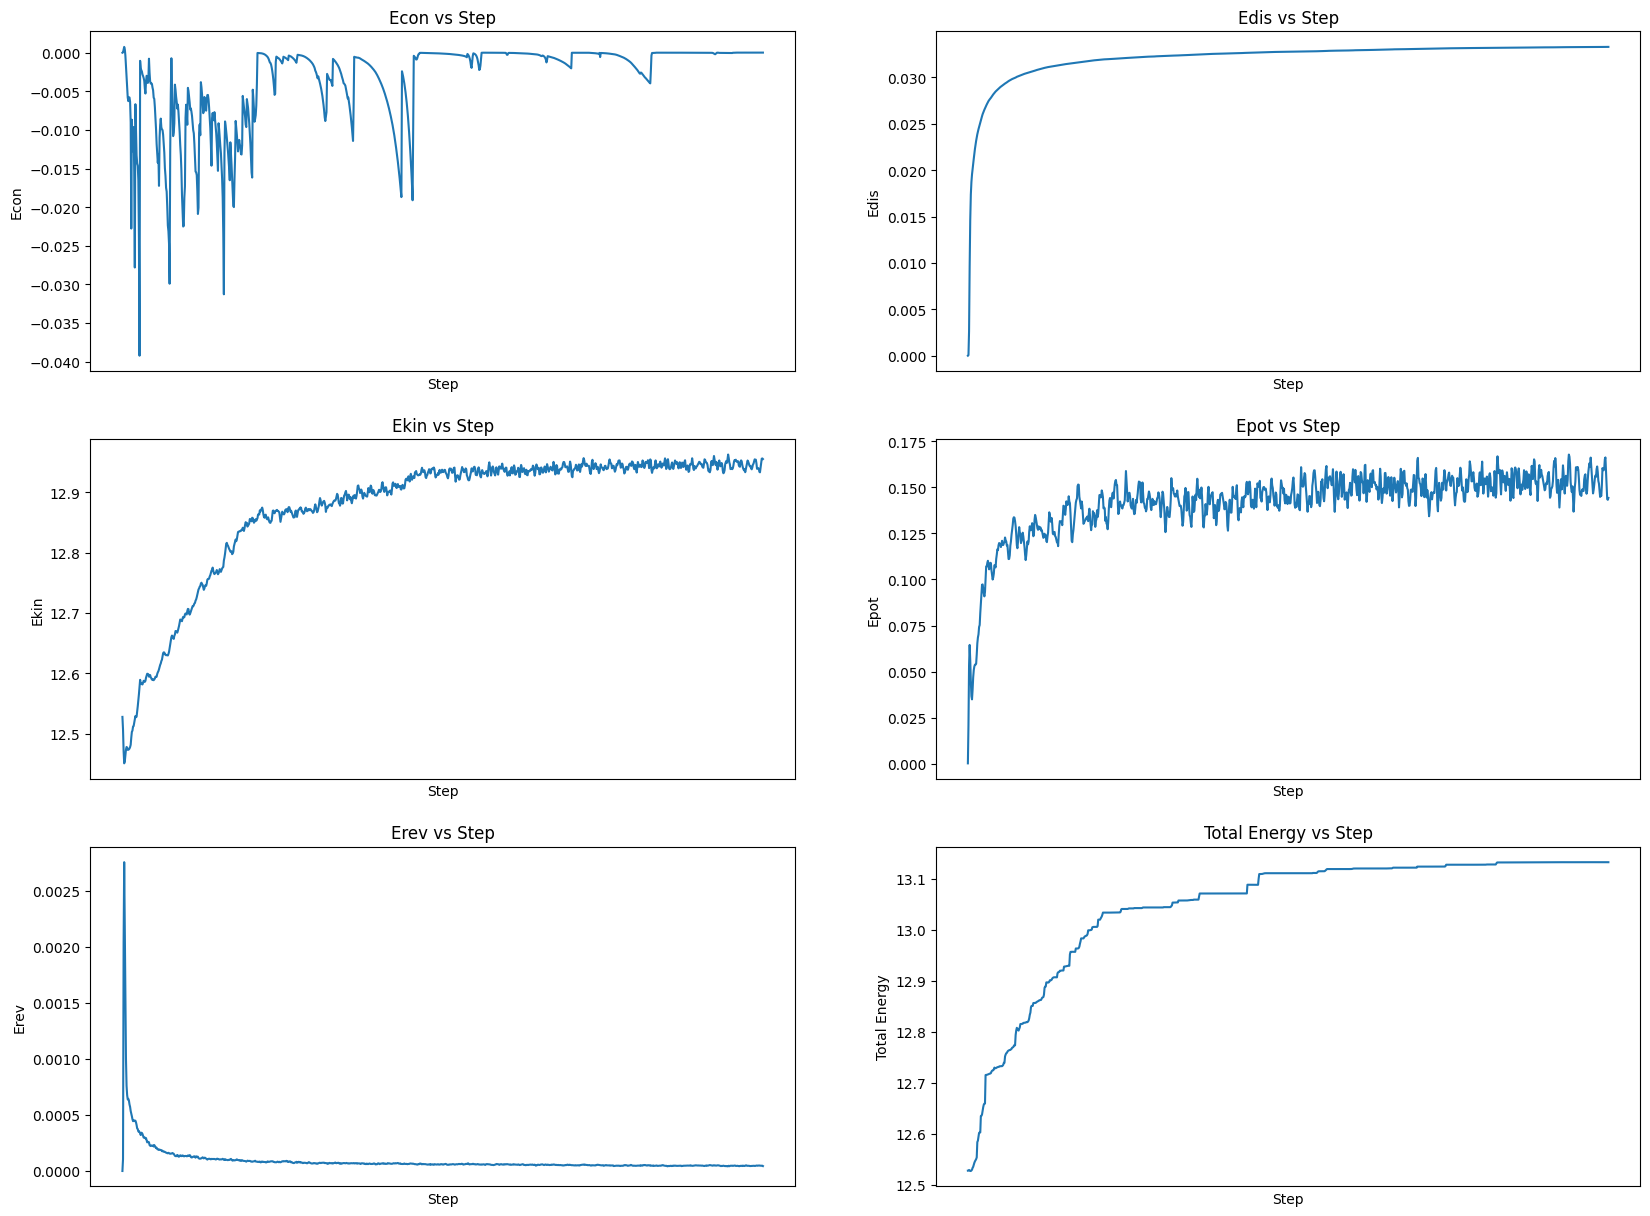

In [10]:
# Plotting the variation of these quantities over time steps
plt.figure(figsize=(20, 15))
plt.subplot(3, 2, 1)
plt.plot(steps, econ, label='Econ')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Econ')
plt.title('Econ vs Step')
plt.subplot(3, 2, 2)
plt.plot(steps, edis, label='Edis')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Edis')
plt.title('Edis vs Step')
plt.subplot(3, 2, 3)
plt.plot(steps, ekin, label='Ekin')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Ekin')
plt.title('Ekin vs Step')
plt.subplot(3, 2, 4)
plt.plot(steps, epot, label='Epot')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Epot')
plt.title('Epot vs Step')
plt.subplot(3, 2, 5)
plt.plot(steps, erev, label='Erev')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Erev')
plt.title('Erev vs Step')
plt.subplot(3, 2, 6)
plt.plot(steps, total_energy, label='Total Energy')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Total Energy')
plt.title('Total Energy vs Step')
plt.show()

In [11]:
# print mean, min, max, std of masses and velocity magnitudes
mean_mass = np.mean(final_masses)
min_mass = np.min(final_masses)
max_mass = np.max(final_masses)
std_mass = np.std(final_masses)
velocity_magnitudes = np.linalg.norm(final_velocities, axis=1)
mean_velocity = np.mean(velocity_magnitudes)
min_velocity = np.min(velocity_magnitudes)
max_velocity = np.max(velocity_magnitudes)
std_velocity = np.std(velocity_magnitudes)
print(f"Masses - Mean: {mean_mass}, Min: {min_mass}, Max: {max_mass}, Std: {std_mass}")
print(f"Velocity Magnitudes - Mean: {mean_velocity}, Min: {min_velocity}, Max: {max_velocity}, Std: {std_velocity}")

Masses - Mean: 1.0146798096714746e-07, Min: 1.7798380986813977e-08, Max: 6.7329707391312355e-06, Std: 3.868583815037938e-07
Velocity Magnitudes - Mean: 320.581693862414, Min: 2.1730590154140557, Max: 1323.9869254210566, Std: 256.2644921279013


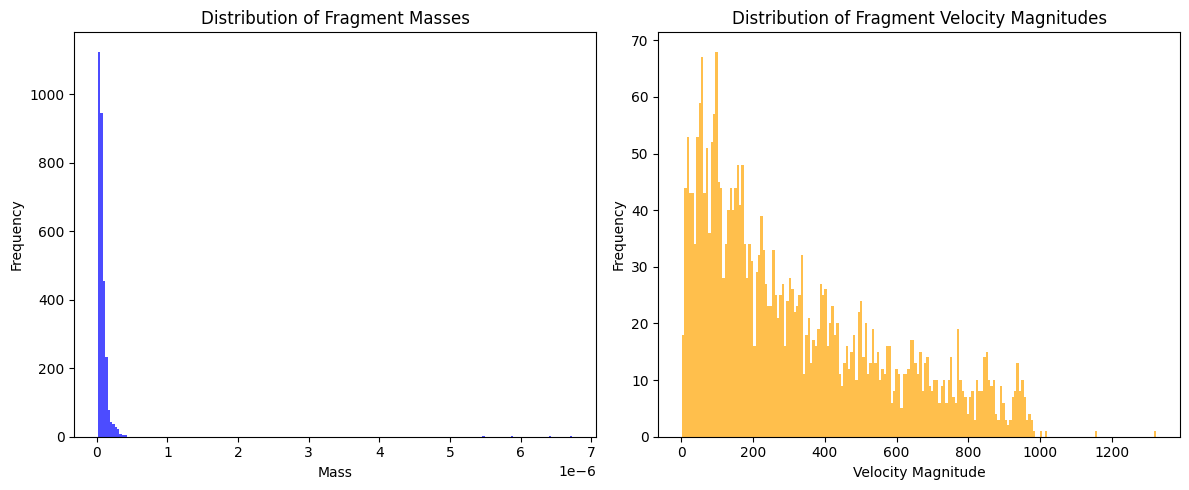

In [12]:
# distribution of masses and velocity magnitudes, really tight bins to see the distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(final_masses, bins=200, color='blue', alpha=0.7)
plt.title('Distribution of Fragment Masses')
plt.xlabel('Mass')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(velocity_magnitudes, bins=200, color='orange', alpha=0.7)
plt.title('Distribution of Fragment Velocity Magnitudes')
plt.xlabel('Velocity Magnitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [13]:
import pyvista as pv

2026-04-20 11:51:15.894 (   9.629s) [    7FD13FC29740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_1752586/790276196.py:28: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


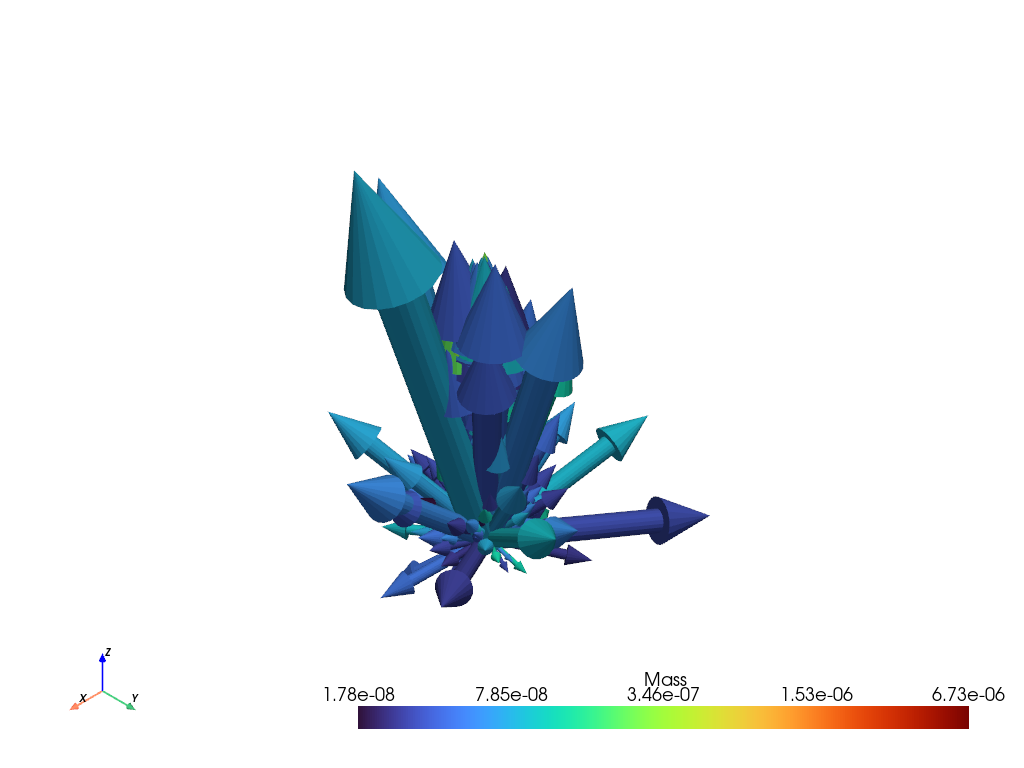

In [14]:
point_cloud = pv.PolyData(final_com)
point_cloud["velocity"] = final_velocities
point_cloud["mass"] = final_masses

# We use the 'velocity' for orientation and magnitude scaling
glyphs = point_cloud.glyph(
    orient="velocity",
    scale=True,  # This scales the arrow length by velocity magnitude
    factor=0.1,
    geom=pv.Arrow(
        tip_radius=0.1,   # Fixed values here
        tip_length=0.25,
        shaft_radius=0.05 
    ),
)

plotter = pv.Plotter()
plotter.add_mesh(
    glyphs,
    scalars="mass",
    cmap="turbo",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Mass"},
    clim=[min_mass, max_mass],
    log_scale=True,
)
plotter.add_axes()
plotter.show()